In [3]:
#import some useful stuff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import os
from pathlib import Path

# Analysis of the open availability of NASA publications

Determine the number of publicatins being produced by NASA by querying two different resources

See Michelson, R, Paseka, R, Crawford, S. 2024. Monitoring Implementation of the NASA Science Mission Directorate Scientific Information Policy for NASA’s Research Opportunities for Earth and Space Science. OSF Registries. https://doi.org/10.17605/OSF.IO/43U8W 

In [6]:
#read in the full CHORUS dataset - this file is downloaded from https://dashboard.chorusaccess.org/nasa#/summary
myfile = "./CHORUS-NASA-2025-07-25-ALL.csv"
myfile = 'CHORUS-NASA-2025-11-25-ALL.csv'
full_chorus = pd.read_csv(myfile)

In [7]:
#take a quick look at the dataframe, see if that worked
full_chorus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59995 entries, 0 to 59994
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   DOI                                    59995 non-null  object
 1   Publisher                              59995 non-null  object
 2   Funders                                59971 non-null  object
 3   Funder Id                              59971 non-null  object
 4   RoRID (Funder)                         59829 non-null  object
 5   Author(s)                              59977 non-null  object
 6   Article Title                          59995 non-null  object
 7   Journal Name                           58160 non-null  object
 8   Online Publication Date                42545 non-null  object
 9   Print Publication Date                 49600 non-null  object
 10  Last Audited On                        52066 non-null  object
 11  Publicly Access

In [8]:
# limit to only journal articles
full_chorus = full_chorus[full_chorus["Type"]=="journal-article"] 

In [9]:
#make the pub dates into datetime objects
full_chorus["Print Publication Date"] = pd.to_datetime(full_chorus["Print Publication Date"], format='mixed')
#give the date column a shorter name for ease of calling
date_column = full_chorus["Print Publication Date"]

In [10]:
full_chorus["Online Publication Date"] = pd.to_datetime(full_chorus["Online Publication Date"], format='mixed')


In [11]:
mask = (full_chorus['Print Publication Date'].dt.year == 2023) | (full_chorus['Online Publication Date'].dt.year == 2023)
pubs_2023 = full_chorus[mask]

In [12]:
mask = (full_chorus['Print Publication Date'].dt.year == 2024) | (full_chorus['Online Publication Date'].dt.year == 2024)
pubs_2024 = full_chorus[mask]

In [13]:
pubs_2024.to_csv('chorus2024.csv')

In [14]:
len(pubs_2024)


5705

In [15]:
pubs_2024.sample(150).to_csv('random_sample.csv')

## Analyze 2023 Data Set

In [16]:
total = len(pubs_2024)
print(total)

5705


In [17]:
total23 = len(pubs_2023)
print(total23)

5798


In [18]:
def analyze_chorus(pubs, year): 
    npub_site = pubs["Publicly Accessible On Publisher Site"].count()
    total = len(pubs)
    print("{frac} out of {total} papers (or {percent}% of papers) are publicly available on their publisher's website".format(frac = npub_site, total=total, percent=round(100*(npub_site/total),2)))
    print()
    #investigate "CHORUS Verified OA" column
    unknown = (pubs["CHORUS Verified OA"] == "Unknown").sum()
    yes = (pubs["CHORUS Verified OA"] == "Yes").sum()
    no = (pubs["CHORUS Verified OA"] == "No").sum()

        
    data = [["Verified OA", yes], ["Not verified OA", no], ["Unknown status", unknown]]
    df = pd.DataFrame(data, columns=['Status', 'Count'])
    print(df)

    #calculate percents off of the above df and make a little plot for funsies
    unk_percent = round(100*unknown/total,1)
    yes_percent = round(100*yes/total,1)
    no_percent = round(100*no/total,1)
    
    plt.title(f"{year} NASA-funded publications verified as open-access by CHORUS")
    plt.bar_label(plt.bar(df["Status"], df["Count"], color=['#FFC107', '#D81B60', '#99BADD']),[f"{yes_percent}%", f"{no_percent}%", f"{unk_percent}%"])
    #plt.show()
    plt.savefig(f"openaccess_chorus{year}.jpg")

2898 out of 5798 papers (or 49.98% of papers) are publicly available on their publisher's website

            Status  Count
0      Verified OA   3006
1  Not verified OA   2100
2   Unknown status    692


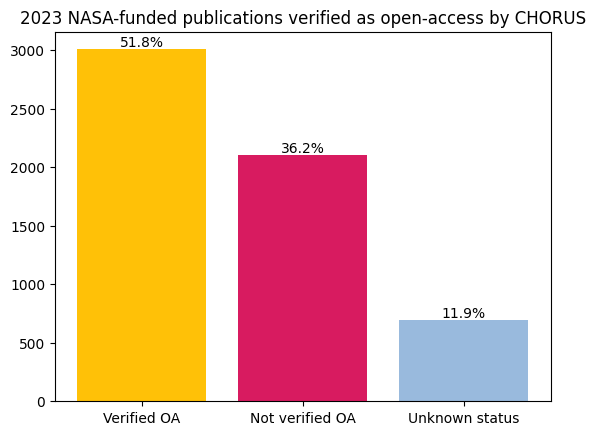

In [19]:
analyze_chorus(pubs_2023, 2023)

2826 out of 5705 papers (or 49.54% of papers) are publicly available on their publisher's website

            Status  Count
0      Verified OA   2886
1  Not verified OA    875
2   Unknown status   1944


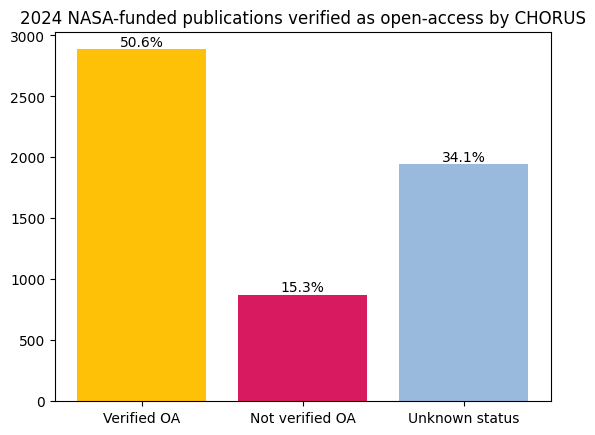

In [20]:
analyze_chorus(pubs_2024, 2024)

In [21]:
years_list = np.array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
total_list = np.zeros(len(years_list))
open_list = np.zeros(len(years_list))

for i in range(len(years_list)):
    year = years_list[i]
    mask = (full_chorus['Print Publication Date'].dt.year == year) | (full_chorus['Online Publication Date'].dt.year == year)
    pubs = full_chorus[mask]

    total = len(pubs)
    noa = (pubs["CHORUS Verified OA"] == "Yes").sum()
    total_list[i] = total
    open_list[i] = noa
    print(year, total, noa)


    

2015 2445 1423
2016 3113 2007
2017 3916 2672
2018 4590 3266
2019 5733 3982
2020 6164 3666
2021 6350 3798
2022 6131 3143
2023 5798 3006
2024 5705 2886


In [22]:
# data from ads
ads_total = np.array([4098, 4234, 4345, 4529, 4582, 4655, 4872, 4710, 4691, 4994])
ads_open = np.array([3141, 3243, 3345, 3594, 3576, 3760, 4021, 3963, 3984, 4209])

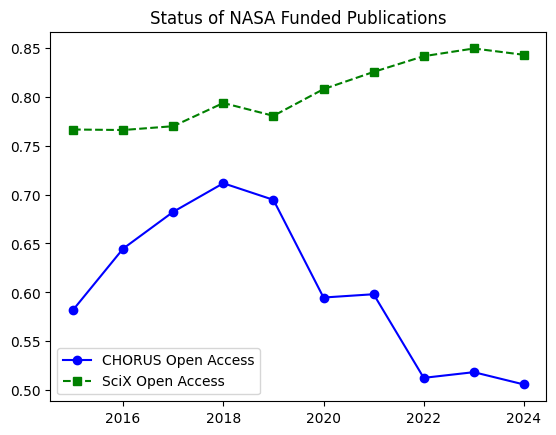

In [23]:
plt.title(f"Status of NASA Funded Publications")
plt.plot(years_list, open_list / total_list, 'bo-', label='CHORUS Open Access')
plt.plot(years_list, ads_open / ads_total, 'gs--', label='SciX Open Access')
plt.legend(loc='lower left')

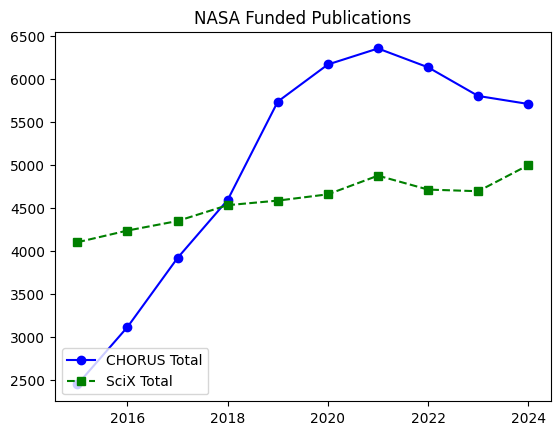

In [24]:
plt.title(f"NASA Funded Publications")
plt.plot(years_list, total_list, 'bo-', label='CHORUS Total')
plt.plot(years_list, ads_total, 'gs--', label='SciX Total')
plt.legend(loc='lower left')

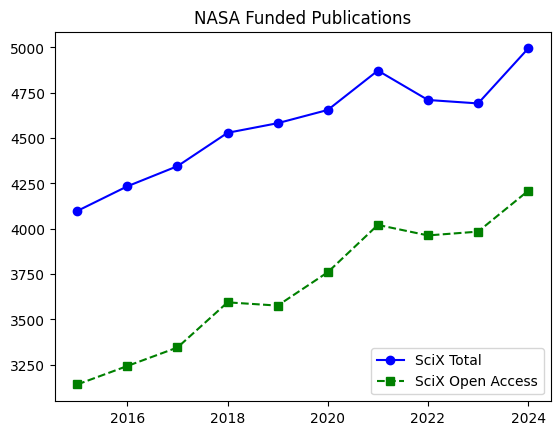

In [25]:
plt.title(f"NASA Funded Publications")
plt.plot(years_list, ads_total, 'bo-', label='SciX Total')
plt.plot(years_list, ads_open, 'gs--', label='SciX Open Access')
plt.legend(loc='lower right')
plt.savefig('scix_pubs.jpg')

In [26]:
ads_open / ads_total

array([0.76647145, 0.76594237, 0.7698504 , 0.79355266, 0.78044522,
       0.80773362, 0.82532841, 0.84140127, 0.84928587, 0.84281137])

## Determine SciX data

##### Numbers as reported by the following queries on Nov 25:

[Total Publications](
https://scixplorer.org/search?q=full%3A%22supported+by+NASA%22+year%3A%222024%22+property%3A%22refereed%22&sort=score+desc&sort=date+desc&p=1&n=10): 5019


[Openly Available Publications](https://scixplorer.org/search?q=full%3A%22supported+by+NASA%22+year%3A%222024%22++property%3A%22open+access%22+property%3A%22refereed%22&sort=score+desc&sort=date+desc&p=1&n=10): 4259


In [30]:
4259 / 5019

0.8485754134289699

This file was created based on a query for 2023 NASA publications from https://scixplorer.org.  It is a composite file made from multiple downloads from the service.  

The SciX query used was: full:"supported by NASA" year:"2023" property:"open access" property:refereed.